In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")



*Impulse Invariance* is a method for creating discrete-time (digital) IIR filters from continuous-time impulse responses:

$$
H(s) \xrightarrow[\text{Invariance}]{\text{Impulse}} H(z)
$$


It involves the following steps:

- 1: Define a frequency response in the Laplace domain.
- 2: Transform to time domain (inverse Laplace).
- 3: **Sample the continuous-time impulse response.**
- 4: Apply z-transform.
- 5: Get filter coefficients.


With the sampling period $T = \frac{1}{f_s}$, the continuous-time impulse response $h_C(t)$ is sampled as follows to produce the discrete-time impulse response $h_D[n]$:

$$
h_D[n] = h_C(nT) 
$$



-----

[\\]:  https://www.engr.colostate.edu/ECE423/lectures_pdf/2009/Lecture08.pdf

For the transfer function, the sampling of the continuous-time transfer function $H_C(j\omega)$
can be expressed as follows:

$$\begin{eqnarray}
H_D(e^{j\omega}) &=& \frac{1}{T} \sum_{k=-\infty}^{\infty} H_C \left( \frac{\omega}{T} - \frac{2\pi k}{T} \right)
\end{eqnarray}$$
 



This sampling can be interpreted as mapping the s plane to the z-plane:

$$
z \triangleq e^{sT} = e^{σT} e^{j\omega T} 
$$


-----


The following plot visualizes the repitition of $H_D(e^{j\omega})$:

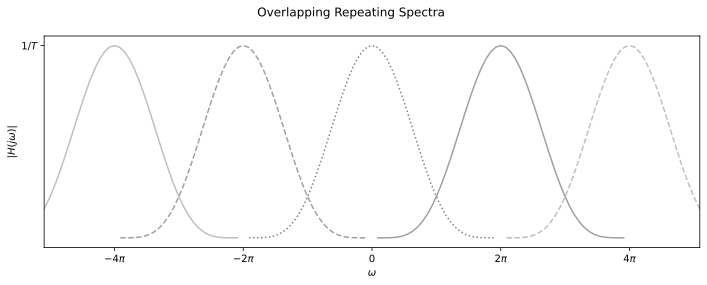

In [6]:

N = 51

f = np.linspace(-6,6,N)
w = signal.windows.hann(N)

plt.figure(figsize=(10, 4))

s = np.arange(-4*np.pi,6*np.pi,2*np.pi)

for i in [-2,-1,0,1,2]:

    plt.plot(f+i*2*np.pi,w*w,'gray',alpha=1-abs(0.5*i/2))



plt.xticks(s,labels=['$-4\pi$' , '$-2\pi$', '0','$2\pi$', '$4\pi$'])
plt.yticks([1],labels=['$1/T$'])


plt.suptitle("Overlapping Repeating Spectra")
plt.ylabel("$|H(j \omega)|$")
plt.xlabel("$\omega$")

plt.xlim([-16,16])
plt.tight_layout()


We see that the repeating spectra overlap, if the signal is not band-limited
This is referred to as **spectrum aliasing** - and has the following consequences:

- The impulse invariance method is not useful for high-pass filters. 
- It is more suitable for Butterworth and Chebyshev I - they have no ripples in the stop-band.

----

[//]: https://spinlab.wpi.edu/courses/ece503_2014/4-2impulse_invariance.pdf
[//]: Essentials_of_Digital_Signal_Processing_(p.501)

# Example: Integrator

A simple example is the integrator - a system with low-pass behavior.
Its **transfer function** has one pole at $s=0$ and is given by:

$$
H_C(s) = \frac{1}{s-a}
$$

The **inverse Laplace transform** is an eponential function
(look up these transform pairs in any [table](https://en.wikipedia.org/wiki/Laplace_transform#Table_of_selected_Laplace_transforms)):

$$
h_C(t) = e^{at} u(t)
$$

This continuous-time transfer function can be digitized by substituting $t$ with $nT$:

$$
h_D[n] = e^{aTn} u[n]
$$

The following plot shows this for $T=0.005$:

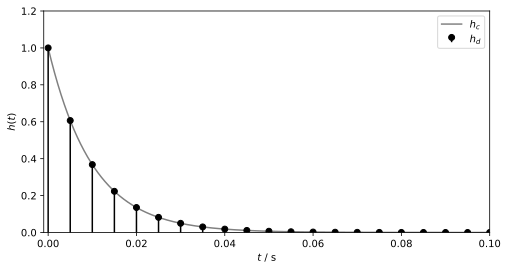

In [3]:
fs = 100
N  = 10000

t  = np.linspace(0,0.1,N)
h  = np.exp(100* -t)

td = np.linspace(0,0.1,21)
hd = np.exp(100*-td)


fig = plt.figure(figsize=(8, 4))
ax1 = plt.subplot(1,1,1)

ax1.plot(t,h, 'gray', label='$h_c$')
ax1.stem(td,hd, 'k', basefmt=" ",markerfmt='ko', label='$h_d$')

ax1.set_xlabel("$t$ / s");
ax1.set_ylabel("$h(t)$");

plt.xlim([-0.001,0.1])
plt.ylim([0,1.2])
plt.legend();


----

Next, we apply the **z-transform** to this impulse response. 
We can again refer to a [table of z-transform pairs](https://en.wikipedia.org/wiki/Z-transform#Table_of_common_Z-transform_pairs) or go back to our [z-transform example](https://ringbuffer.org/dsp/Digital_Filters/z_transform/#Anti-Causal-Signal) to get the following relation:

$\alpha^n u[n] \Rightarrow \frac{1}{1-\alpha z^{-1}}$, with: $\alpha = e^{aT}$

Using this relation, the discrete-time transfer function results in:

$$
\boxed{H_D(z) = \frac{1}{1 -e^{aT} z^{-1}}}
$$

We can directly get our single coefficient from the transfer function:

$$
a_0 = -e^{aT}
$$

And create the difference equation:

$$
y[n] = x[n] -e^{aT} y[n-1]
$$

----

$H_D(z)$ has **one pole** at:

$$
|z| = e^{aT}
$$

And the **ROC** is:

$$
|z| > e^{aT}
$$

----


We can now investigate the system behavior for different values of a with a fixed $T=1$:



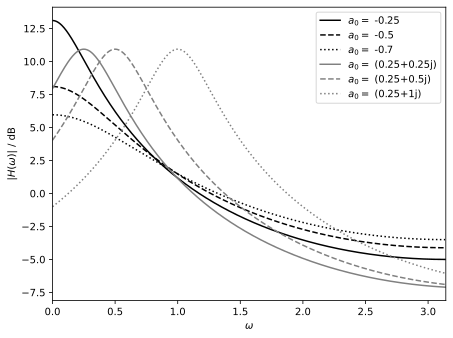

In [4]:
import numpy as np
import scipy.signal as signal
from cycler import cycler

monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

fig, ax1 = plt.subplots(tight_layout=True)


def plotter(AA):

    T = 1

    poles = [np.exp(T*AA)] 
    zeros = []
    gain  = 1
    
    # Convert poles/zeros to transfer function (numerator and denominator coefficients)
    b, a = signal.zpk2tf(zeros, poles, gain)
    
    # Create a discrete-time transfer function
    system  = signal.dlti(b, a, dt=1)  # dt=1 for a unit sample time
    w,h      = signal.freqz(b,a)
    
    ax1.plot(w, 20 * np.log10(abs(h)), label='$a_0 =$ '+str(AA))



plotter(-0.25 )
plotter(-0.5 )
plotter(-0.7)
plotter(0.25 +0.25j)
plotter(0.25 +0.5j)
plotter(0.25 +1j)


ax1.set_ylabel("$|H(\omega)|$ / dB")
ax1.set(xlabel="$\omega$", xlim=(0, np.pi));

#print("Numerator Coefficients:", b)
#print("Denominator Coefficients:", a)
 
plt.legend();

